In [1]:
import math
from tempfile import NamedTemporaryFile

import pandas as pd
from IPython.display import Image
from pgmpy.factors.discrete import TabularCPD
from pgmpy.inference import VariableElimination
from pgmpy.models import DiscreteBayesianNetwork
from tabulate import tabulate

/Users/stevensamson/Projects/JohnsHopkins/605_745_reasoning_under_uncertainty/.venv/lib/python3.12/site-packages/pgmpy/estimators/__init__.py:4: FutureWarning: `pgmpy.estimators.StructureScore` is deprecated and will be removed in v1.3.0. Use `pgmpy.structure_score` instead.
  from .StructureScore import (


## Question 1

```
a	b	c	p(a, b, c)
0	0	0	0.192
0	0	1	0.144
0	1	0	0.048
0	1	1	0.216
1	0	0	0.192
1	0	1	0.064
1	1	0	0.048
1	1	1	0.096
```

Are a and b independent? (Test whether p(a ∩ b) = p(a)·p(b).)

In [2]:
prob_table = [
    [0, 0, 0, 0.192],
    [0, 0, 1, 0.144],
    [0, 1, 0, 0.048],
    [0, 1, 1, 0.216],
    [1, 0, 0, 0.192],
    [1, 0, 1, 0.064],
    [1, 1, 0, 0.048],
    [1, 1, 1, 0.096],
]

joint_prob_df = pd.DataFrame(prob_table, columns=["a", "b", "c", "prob"])

print(
    tabulate(
        joint_prob_df,
        headers="keys",
        floatfmt=[".0f", ".0f", ".0f", ".3f"],
        showindex=False,
    )
)

  a    b    c    prob
---  ---  ---  ------
  0    0    0   0.192
  0    0    1   0.144
  0    1    0   0.048
  0    1    1   0.216
  1    0    0   0.192
  1    0    1   0.064
  1    1    0   0.048
  1    1    1   0.096


The value of $p(a, b) = p(a, b, c) + p(a, b, \neg c)$.

In [3]:
joint_ab = joint_prob_df.groupby(by=["a", "b"])["prob"].sum().reset_index()

print(
    tabulate(
        joint_ab,
        headers=["a", "b", "prob"],
        floatfmt=[".0f", ".0f", ".3f"],
        showindex=False,
    )
)

  a    b    prob
---  ---  ------
  0    0   0.336
  0    1   0.264
  1    0   0.256
  1    1   0.144


The value of $p(a) = p(a, b) + p(a, \neg b)$ and $p(b) = p(a, b) + p(\neg a, b)$.

In [4]:
marginal_a = joint_prob_df.groupby(by=["a"])["prob"].sum().reset_index()

print(
    tabulate(
        marginal_a, headers=["a", "prob"], floatfmt=[".0f", ".3f"], showindex=False
    )
)

  a    prob
---  ------
  0   0.600
  1   0.400


In [5]:
marginal_b = joint_prob_df.groupby(by=["b"])["prob"].sum().reset_index()

print(
    tabulate(
        marginal_b, headers=["b", "prob"], floatfmt=[".0f", ".3f"], showindex=False
    )
)

  b    prob
---  ------
  0   0.592
  1   0.408


If $p(a, b) = p(a)p(b)$, then the entries in the previously computed $p(a, b)$ from marginalization should be the same as multiplying the singular marginals.

In [6]:
question_1_values = []

for a in joint_prob_df.a.unique():
    for b in joint_prob_df.b.unique():
        prob_joint = joint_ab.query(f"a == {a} and b == {b}").prob.values[0]
        prob_product = (
            marginal_a.query(f"a == {a}").prob.values[0]
            * marginal_b.query(f"b == {b}").prob.values[0]
        )
        are_equal = math.isclose(prob_joint, prob_product)
        question_1_values.append([a, b, prob_joint, prob_product, are_equal])

print(
    tabulate(
        question_1_values,
        headers=["a", "b", "p(a, b)", "p(a) * p(b)", "equal?"],
        floatfmt=".3f",
    )
)

  a    b    p(a, b)    p(a) * p(b)  equal?
---  ---  ---------  -------------  --------
  0    0      0.336          0.355  False
  0    1      0.264          0.245  False
  1    0      0.256          0.237  False
  1    1      0.144          0.163  False


**The value of $p(a, b)$ is *not* independent since $p(a, b) \ne p(a) p(b)$.**

## Question 2

```
a	b	c	p(a, b, c)
0	0	0	0.192
0	0	1	0.144
0	1	0	0.048
0	1	1	0.216
1	0	0	0.192
1	0	1	0.064
1	1	0	0.048
1	1	1	0.096
```

Are a and b conditionally independent given c? (Test whether p(a ∩ b | c) = p(a | c)·p(b | c).)

By the formula for conditional probability, $p(a, b \mid c) = \frac{p(a, b, c)}{p(c)}$. For the denominator, marginalizing the joint should provide $p(c)$:

$$
\begin{align*}
    p(c) &= \sum_{a}\sum_{b} p(a, b, c)
\end{align*}
$$

In [7]:
marginal_c = joint_prob_df.groupby(by=["c"]).prob.sum().reset_index()

print(
    tabulate(
        marginal_c, headers=["c", "prob"], floatfmt=[".0f", ".3f"], showindex=False
    )
)

  c    prob
---  ------
  0   0.480
  1   0.520


Using this to find $p(a, b \mid c)$ and $p(a, b \mid \neg c)$:

In [8]:
joint_ab_given_c = (
    joint_prob_df.query("c == 1").groupby(by=["a", "b"]).prob.sum().reset_index()
)
joint_ab_given_c.prob = (
    joint_ab_given_c.prob / marginal_c.query("c == 1").prob.values[0]
)

print("p(a, b | c = 0):")
print(
    tabulate(
        joint_ab_given_c,
        headers=["a", "b", "prob"],
        floatfmt=[".0f", ".0f", ".3f"],
        showindex=False,
    )
)

p(a, b | c = 0):
  a    b    prob
---  ---  ------
  0    0   0.277
  0    1   0.415
  1    0   0.123
  1    1   0.185


In [9]:
joint_ab_given_not_c = (
    joint_prob_df.query("c == 0").groupby(by=["a", "b"]).prob.sum().reset_index()
)
joint_ab_given_not_c.prob = (
    joint_ab_given_not_c.prob / marginal_c.query("c == 0").prob.values[0]
)

print("p(a, b | c = 0):")
print(
    tabulate(
        joint_ab_given_not_c,
        headers=["a", "b", "prob"],
        floatfmt=[".0f", ".0f", ".3f"],
        showindex=False,
    )
)

p(a, b | c = 0):
  a    b    prob
---  ---  ------
  0    0   0.400
  0    1   0.100
  1    0   0.400
  1    1   0.100


Finding the conditionals for $p(a | c)$ and $p(b | c)$ is the same marginalization exercise as before, but with the conditionals:

$$
\begin{align*}
    p(a \mid c) &= \sum_{b} p(a, b \mid  c) \\
    p(b \mid c) &= \sum_{a} p(a, b \mid  c) \\
\end{align*}
$$


In [10]:
marginal_a_given_c = joint_ab_given_c.groupby(by=["a"]).prob.sum().reset_index()
print("p(a | c = 1):")
print(
    tabulate(
        marginal_a_given_c,
        headers=["a", "prob"],
        floatfmt=[".0f", ".3f"],
        showindex=False,
    )
)

p(a | c = 1):
  a    prob
---  ------
  0   0.692
  1   0.308


In [11]:
marginal_a_given_not_c = joint_ab_given_not_c.groupby(by=["a"]).prob.sum().reset_index()
print("p(a | c = 0):")
print(
    tabulate(
        marginal_a_given_not_c,
        headers=["a", "prob"],
        floatfmt=[".0f", ".3f"],
        showindex=False,
    )
)

p(a | c = 0):
  a    prob
---  ------
  0   0.500
  1   0.500


In [12]:
marginal_b_given_c = joint_ab_given_c.groupby(by=["b"]).prob.sum().reset_index()
print("p(b | c = 1):")
print(
    tabulate(
        marginal_b_given_c,
        headers=["b", "prob"],
        floatfmt=[".0f", ".3f"],
        showindex=False,
    )
)

p(b | c = 1):
  b    prob
---  ------
  0   0.400
  1   0.600


In [13]:
marginal_b_given_not_c = joint_ab_given_not_c.groupby(by=["b"]).prob.sum().reset_index()
print("p(b | c = 0):")
print(
    tabulate(
        marginal_b_given_not_c,
        headers=["b", "prob"],
        floatfmt=[".0f", ".3f"],
        showindex=False,
    )
)

p(b | c = 0):
  b    prob
---  ------
  0   0.800
  1   0.200


Now checking if $p(a, b \mid c) = p(a \mid c) p(b \mid c)$:

In [14]:
question_2_values_c = []

for a in joint_prob_df.a.unique():
    for b in joint_prob_df.b.unique():
        prob_conditional_joint = joint_ab_given_c.query(
            f"a == {a} and b == {b}"
        ).prob.values[0]
        prob_conditional_product = (
            marginal_a_given_c.query(f"a == {a}").prob.values[0]
            * marginal_b_given_c.query(f"b == {b}").prob.values[0]
        )
        are_equal = math.isclose(prob_conditional_joint, prob_conditional_product)
        question_2_values_c.append(
            [a, b, prob_conditional_joint, prob_conditional_product, are_equal]
        )

print(
    tabulate(
        question_2_values_c,
        headers=["a", "b", "p(a, b | c = 1)", "p(a | c = 1) * p(b | c = 1)", "equal?"],
        floatfmt=".3f",
    )
)

  a    b    p(a, b | c = 1)    p(a | c = 1) * p(b | c = 1)  equal?
---  ---  -----------------  -----------------------------  --------
  0    0              0.277                          0.277  True
  0    1              0.415                          0.415  True
  1    0              0.123                          0.123  True
  1    1              0.185                          0.185  True


In [15]:
question_2_values_not_c = []

for a in joint_prob_df.a.unique():
    for b in joint_prob_df.b.unique():
        prob_conditional_joint = joint_ab_given_not_c.query(
            f"a == {a} and b == {b}"
        ).prob.values[0]
        prob_conditional_product = (
            marginal_a_given_not_c.query(f"a == {a}").prob.values[0]
            * marginal_b_given_not_c.query(f"b == {b}").prob.values[0]
        )
        are_equal = math.isclose(prob_conditional_joint, prob_conditional_product)
        question_2_values_not_c.append(
            [a, b, prob_conditional_joint, prob_conditional_product, are_equal]
        )

print(
    tabulate(
        question_2_values_not_c,
        headers=["a", "b", "p(a, b | c = 0)", "p(a | c = 0) * p(b | c = 0)", "equal?"],
        floatfmt=".3f",
    )
)

  a    b    p(a, b | c = 0)    p(a | c = 0) * p(b | c = 0)  equal?
---  ---  -----------------  -----------------------------  --------
  0    0              0.400                          0.400  True
  0    1              0.100                          0.100  True
  1    0              0.400                          0.400  True
  1    1              0.100                          0.100  True


**In this case, $p(a, b \mid c) = p(a \mid c) p(b \mid c)$ is true**.

## Question 3

Which pairs are d-separated by {A}?

![PS3_Figure2_Network.png](PS3_Figure2_Network.png)

In [16]:
# https://pgmpy.org/examples/Creating_Discrete_BN.html
question3_model = DiscreteBayesianNetwork([
    ("A", "B"),
    ("A", "C"),
    ("A", "D"),
    ("B", "D"),
    ("B", "E"),
    ("C", "E"),
    ("E", "F")
])

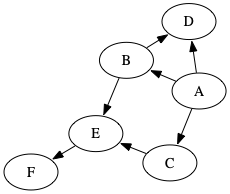

In [17]:
q3_viz = question3_model.to_graphviz()

with NamedTemporaryFile(suffix=".png") as tmp:
    q3_viz.draw(tmp.name, prog="neato")
    display(Image(tmp.name))

In [18]:
# https://pgmpy.org/examples/Basic_Operations_on_BN.html#D-Separation
print(f"(B, C) d-separated?: {not question3_model.is_dconnected("B", "C", observed=["A"])}")
print(f"(C, D) d-separated?: {not question3_model.is_dconnected("C", "D", observed=["A"])}")
print(f"(D, E) d-separated?: {not question3_model.is_dconnected("D", "E", observed=["A"])}")

(B, C) d-separated?: True
(C, D) d-separated?: True
(D, E) d-separated?: False


## Question 4

Which pairs are d-separated by {A, F}?

![PS3_Figure2_Network.png](PS3_Figure2_Network.png)

In [19]:
# https://pgmpy.org/examples/Basic_Operations_on_BN.html#D-Separation
print(f"(B, C) d-separated?: {not question3_model.is_dconnected("B", "C", observed=["A", "F"])}")
print(f"(C, D) d-separated?: {not question3_model.is_dconnected("C", "D", observed=["A", "F"])}")
print(f"(D, F) d-separated?: {not question3_model.is_dconnected("D", "F", observed=["A"])}")

(B, C) d-separated?: False
(C, D) d-separated?: False
(D, F) d-separated?: False


## Question 5

Which pairs are d-separated by {B, C}?

![PS3_Figure2_Network.png](PS3_Figure2_Network.png)

In [20]:
# https://pgmpy.org/examples/Basic_Operations_on_BN.html#D-Separation
print(f"(A, D) d-separated?: {not question3_model.is_dconnected("A", "D", observed=["B", "C"])}")
print(f"(A, E) d-separated?: {not question3_model.is_dconnected("A", "E", observed=["B", "C"])}")
print(f"(A, F) d-separated?: {not question3_model.is_dconnected("A", "F", observed=["B", "C"])}")
print(f"(D, E) d-separated?: {not question3_model.is_dconnected("D", "E", observed=["B", "C"])}")
print(f"(D, F) d-separated?: {not question3_model.is_dconnected("D", "F", observed=["B", "C"])}")

(A, D) d-separated?: False
(A, E) d-separated?: True
(A, F) d-separated?: True
(D, E) d-separated?: True
(D, F) d-separated?: True


# Question 6

After initialization (no evidence), what is P(c1)?

![PS3_Figure3_Diagnostic_Tree.png](PS3_Figure3_Diagnostic_Tree.png)

In [21]:
# https://pgmpy.org/examples/Creating_Discrete_BN.html
question6_model = DiscreteBayesianNetwork([
    ("A", "B"),
    ("A", "C"),
    ("C", "E"),
    ("C", "D"),
])

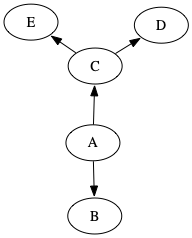

In [22]:
q6_viz = question6_model.to_graphviz()

with NamedTemporaryFile(suffix=".png") as tmp:
    q6_viz.draw(tmp.name, prog="neato")
    display(Image(tmp.name))

In [23]:
# https://pgmpy.org/examples/Creating_Discrete_BN.html#2.-Defining-the-Model-Manually
cpd_a = TabularCPD(
    variable="A",
    variable_card=2,
    values=[[0.5], [0.5]],
    state_names={
        "A": ["a1", "a2"],
    }
)

cpd_b = TabularCPD(
    variable="B",
    variable_card=2,
    values=[
        [0.33, 0.60],  # P(B=b1 | A=a1), P(B=b1 | A=a2)
        [0.67, 0.40],  # P(B=b2 | A=a1), P(B=b2 | A=a2)
    ],
    evidence=["A"],
    evidence_card=[2],
    state_names={
        "A": ["a1", "a2"],
        "B": ["b1", "b2"],
    }
)

cpd_c = TabularCPD(
    variable="C",
    variable_card=2,
    values=[
        [0.13, 0.005],  # P(C=c1 | A=a1), P(C=c1 | A=a2)
        [0.87, 0.995],  # P(C=c2 | A=a1), P(C=c2 | A=a2)
    ],
    evidence=["A"],
    evidence_card=[2],
    state_names={
        "A": ["a1", "a2"],
        "C": ["c1", "c2"],
    }
)

cpd_d = TabularCPD(
    variable="D",
    variable_card=2,
    values=[
        [0.4, 0.2],  # P(D=c1 | C=c1), P(D=c1 | C=c2)
        [0.6, 0.8],  # P(D=c2 | C=c1), P(D=c2 | C=c2)
    ],
    evidence=["C"],
    evidence_card=[2],
    state_names={
        "C": ["c1", "c2"],
        "D": ["d1", "d2"],
    }
)

cpd_e = TabularCPD(
    variable="E",
    variable_card=2,
    values=[
        [0.75, 0.45],  # P(E=e1 | C=c1), P(E=e1 | C=c2)
        [0.25, 0.55],  # P(E=e2 | C=c1), P(E=e2 | C=c2)
    ],
    evidence=["C"],
    evidence_card=[2],
    state_names={
        "C": ["c1", "c2"],
        "E": ["e1", "e2"],
    }
)

question6_model.add_cpds(cpd_a, cpd_b, cpd_c, cpd_d, cpd_e)
print(f"Question 6 with CPDs valid?: {question6_model.check_model()}")

Question 6 with CPDs valid?: True


In [24]:
# https://pgmpy.org/examples/Inference_Discrete_BN.html
question6_inference = VariableElimination(question6_model)

In [25]:
# P(c1)
q6 = question6_inference.query(variables=["C"])
print(q6)

+-------+----------+
| C     |   phi(C) |
+=======+==========+
| C(c1) |   0.0675 |
+-------+----------+
| C(c2) |   0.9325 |
+-------+----------+


# Question 7

After initialization (no evidence), what is P(d1)?

![PS3_Figure3_Diagnostic_Tree.png](PS3_Figure3_Diagnostic_Tree.png)

In [26]:
# P(d1)
q7 = question6_inference.query(variables=["D"])
print(q7)

+-------+----------+
| D     |   phi(D) |
+=======+==========+
| D(d1) |   0.2135 |
+-------+----------+
| D(d2) |   0.7865 |
+-------+----------+


# Question 8

Now instantiate C = c1. What is the updated belief P(a1 | c1)?

![PS3_Figure3_Diagnostic_Tree.png](PS3_Figure3_Diagnostic_Tree.png)

In [27]:
# P(a1 | c1)
q8 = question6_inference.query(variables=["A"], evidence={"C": "c1"})
print(q8)

+-------+----------+
| A     |   phi(A) |
+=======+==========+
| A(a1) |   0.9630 |
+-------+----------+
| A(a2) |   0.0370 |
+-------+----------+


# Question 9

Now instantiate C = c1. What is the updated belief P(b1 | c1)?

![PS3_Figure3_Diagnostic_Tree.png](PS3_Figure3_Diagnostic_Tree.png)

In [28]:
# P(b1 | c1)
q9 = question6_inference.query(variables=["B"], evidence={"C": "c1"})
print(q9)

+-------+----------+
| B     |   phi(B) |
+=======+==========+
| B(b1) |   0.3400 |
+-------+----------+
| B(b2) |   0.6600 |
+-------+----------+


# Question 10

Now instantiate C = c1. What is the updated belief P(d1 | c1)?

![PS3_Figure3_Diagnostic_Tree.png](PS3_Figure3_Diagnostic_Tree.png)

In [29]:
# P(d1 | c1)
q10 = question6_inference.query(variables=["D"], evidence={"C": "c1"})
print(q10)

+-------+----------+
| D     |   phi(D) |
+=======+==========+
| D(d1) |   0.4000 |
+-------+----------+
| D(d2) |   0.6000 |
+-------+----------+


# Question 11

Compute P(h1, b2, l1, f2, c2), the probability that H is true, B false, L true, F false, and C false.

![PS3_Figure4_Smoking_Diagnosis.png](PS3_Figure4_Smoking_Diagnosis.png)

In [30]:
# https://pgmpy.org/examples/Creating_Discrete_BN.html
question11_model = DiscreteBayesianNetwork([
    ("H", "B"),
    ("H", "L"),
    ("B", "F"),
    ("L", "F"),
    ("L", "C"),
])

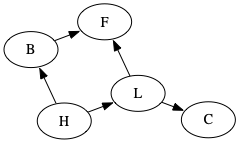

In [31]:
q11_viz = question11_model.to_graphviz()

with NamedTemporaryFile(suffix=".png") as tmp:
    q11_viz.draw(tmp.name, prog="neato")
    display(Image(tmp.name))

In [32]:
# https://pgmpy.org/examples/Creating_Discrete_BN.html#2.-Defining-the-Model-Manually
cpd_h = TabularCPD(
    variable="H",
    variable_card=2,
    values=[[0.2], [0.8]],
    state_names={
        "H": ["h1", "h2"],
    }
)

cpd_11_b = TabularCPD(
    variable="B",
    variable_card=2,
    values=[
        [0.25, 0.05],  # P(B=b1 | H=h1), P(B=b1 | H=h2)
        [0.75, 0.95],  # P(B=b2 | H=h1), P(B=b2 | H=h2)
    ],
    evidence=["H"],
    evidence_card=[2],
    state_names={
        "H": ["h1", "h2"],
        "B": ["b1", "b2"],
    }
)

cpd_l = TabularCPD(
    variable="L",
    variable_card=2,
    values=[
        [0.003, 0.0005],  # P(L=l1 | H=h1), P(L=l1 | H=h2)
        [0.997, 0.9995],  # P(L=l2 | H=h1), P(L=l2 | H=h2)
    ],
    evidence=["H"],
    evidence_card=[2],
    state_names={
        "H": ["h1", "h2"],
        "L": ["l1", "l2"],
    }
)

cpd_f = TabularCPD(
    variable="F",
    variable_card=2,
    values=[
        [0.75, 0.10, 0.5, 0.05],  # P(F=f1 | B=b1, L=l1), P(F=f1 | B=b1, L=l2), P(F=f1 | B=b2, L=l1), P(F=f1 | B=b2, L=l2), 
        [0.25, 0.90, 0.5, 0.95],  # P(F=f2 | B=b1, L=l1), P(F=f2 | B=b1, L=l2), P(F=f2 | B=b2, L=l1), P(F=f2 | B=b2, L=l2), 
    ],
    evidence=["B", "L"],
    evidence_card=[2, 2],
    state_names={
        "B": ["b1", "b2"],
        "L": ["l1", "l2"],
        "F": ["f1", "f2"],
    }
)

cpd_11_c = TabularCPD(
    variable="C",
    variable_card=2,
    values=[
        [0.6, 0.02],  # P(C=c1 | L=l1), P(C=c1 | L=l2)
        [0.4, 0.98],  # P(C=c2 | L=l1), P(C=c2 | L=l2)
    ],
    evidence=["L"],
    evidence_card=[2],
    state_names={
        "C": ["c1", "c2"],
        "L": ["l1", "l2"],
    }
)

question11_model.add_cpds(cpd_h, cpd_11_b, cpd_l, cpd_f, cpd_11_c)
print(f"Question 11 with CPDs valid?: {question11_model.check_model()}")

Question 11 with CPDs valid?: True


In [33]:
# https://pgmpy.org/examples/Inference_Discrete_BN.html
question11_inference = VariableElimination(question11_model)

In [34]:
# https://pgmpy.org/examples/Inference_Discrete_BN.html#Step-3:-Doing-Inference-using-hard-evidence
q11 = question11_inference.query(variables=["H", "B", "L", "F", "C"])
print(q11)

+-------+-------+-------+-------+-------+------------------+
| H     | B     | L     | F     | C     |   phi(H,B,L,F,C) |
+=======+=======+=======+=======+=======+==================+
| H(h1) | B(b1) | L(l1) | F(f1) | C(c1) |           0.0001 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l1) | F(f1) | C(c2) |           0.0000 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l1) | F(f2) | C(c1) |           0.0000 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l1) | F(f2) | C(c2) |           0.0000 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l2) | F(f1) | C(c1) |           0.0001 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l2) | F(f1) | C(c2) |           0.0049 |
+-------+-------+-------+-------+-------+------------------+
| H(h1) | B(b1) | L(l2) | F(f2) | C(c1) |           0.0009 |
+-------+-------+-------

In [35]:
# P(h1, b2, l1, f2, c2)
print(q11.get_value(H="h1", B="b2", L="l1", F="f2", C="c2"))

9.000000000000002e-05


# Question 12

Compute P(f1 | l1), the probability F is true given L is true.

![PS3_Figure4_Smoking_Diagnosis.png](PS3_Figure4_Smoking_Diagnosis.png)

In [36]:
# P(h1, b2, l1, f2, c2)
q12 = question11_inference.query(variables=["F"], evidence={"L": "l1"})
print(q12)

+-------+----------+
| F     |   phi(F) |
+=======+==========+
| F(f1) |   0.5425 |
+-------+----------+
| F(f2) |   0.4575 |
+-------+----------+


# Question 13

Compute P(∼B | ∼F) = P(b2 | f2).

![PS3_Figure4_Smoking_Diagnosis.png](PS3_Figure4_Smoking_Diagnosis.png)

In [37]:
# P(b2 | f2)
q13 = question11_inference.query(variables=["B"], evidence={"F": "f2"})
print(q13)

+-------+----------+
| B     |   phi(B) |
+=======+==========+
| B(b1) |   0.0856 |
+-------+----------+
| B(b2) |   0.9144 |
+-------+----------+
